# 01 — Ingestion Quickstart

This notebook demonstrates Sentinel's **Ingestion** module:

1. Using built-in parsers (`WASParser`, `HSMParser`) with synthetic log data
2. Using `LogIngestor` for type-based dispatch
3. Building a custom regex-based parser for complex multi-field log formats

All log data is generated inline — no external files needed.

In [1]:
import pandas as pd
import tempfile
import os

---
## 1. Built-in Parser: WASParser

The `WASParser` handles WebSphere Application Server logs. Each log entry starts with a timestamp/level/thread header, followed by lines containing transaction details extracted via regex patterns (transaction IDs, account numbers, amounts, response codes, etc.).

Let's generate synthetic WAS-format logs and parse them.

In [2]:
was_log_content = """[2025-01-15 08:00:01.123] [INFO] [WebContainer : 1] com.bank.transfer.TransferService
  TRNUID="100001"
  <ACCTFROM><ACCTID>1234-5678-9012</ACCTID></ACCTFROM>
  <ACCTTO><ACCTID>9876-5432-1098</ACCTID></ACCTTO>
  <TRNAMT>1500.00</TRNAMT>
  <STATUS CODE="200" />
  TramaRQ iSeries:REQ_PAYLOAD_TRANSFER_001
  TramaRQ UUID:a1b2c3d4-e5f6-7890-abcd-ef1234567890
  TramaRS iSeries:RS_PAYLOAD_TRANSFER_001_OK
  process transaction 100001
  ConnectionGroup: POOL_TRANSFER_A
[2025-01-15 08:00:05.456] [ERROR] [WebContainer : 3] com.bank.transfer.TransferService
  TRNUID="100002"
  <ACCTFROM><ACCTID>2222-3333-4444</ACCTID></ACCTFROM>
  <ACCTTO><ACCTID>5555-6666-7777</ACCTID></ACCTTO>
  <TRNAMT>25000.50</TRNAMT>
  <STATUS CODE="500" />
  TramaRQ iSeries:REQ_PAYLOAD_TRANSFER_002
  TramaRQ UUID:b2c3d4e5-f6a7-8901-bcde-f12345678901
  TramaRS iSeries:RS_PAYLOAD_TRANSFER_002_FAIL
  process transaction 100002
  ConnectionGroup: POOL_TRANSFER_B
[2025-01-15 08:01:10.789] [INFO] [WebContainer : 2] com.bank.payment.PaymentGateway
  TRNUID="100003"
  <ACCTFROM><ACCTID>8888-9999-0000</ACCTID></ACCTFROM>
  <ACCTTO><ACCTID>1111-2222-3333</ACCTID></ACCTTO>
  <TRNAMT>750.25</TRNAMT>
  <STATUS CODE="200" />
  TramaRQ iSeries:REQ_PAYLOAD_PAYMENT_003
  TramaRQ UUID:c3d4e5f6-a7b8-9012-cdef-123456789012
  TramaRS iSeries:RS_PAYLOAD_PAYMENT_003_OK
  process transaction 100003
  ConnectionGroup: POOL_PAYMENT_A
[2025-01-15 08:02:30.321] [WARN] [WebContainer : 5] com.bank.transfer.TransferService
  TRNUID="100004"
  <ACCTFROM><ACCTID>4444-5555-6666</ACCTID></ACCTFROM>
  <ACCTTO><ACCTID>7777-8888-9999</ACCTID></ACCTTO>
  <TRNAMT>3200.00</TRNAMT>
  <STATUS CODE="408" />
  TramaRQ iSeries:REQ_PAYLOAD_TRANSFER_004
  TramaRQ UUID:d4e5f6a7-b8c9-0123-defa-234567890123
  TramaRS iSeries:RS_PAYLOAD_TRANSFER_004_TIMEOUT
  process transaction 100004
  ConnectionGroup: POOL_TRANSFER_A
"""

# Write to temp file
was_tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.log', delete=False)
was_tmp.write(was_log_content)
was_tmp.close()
print(f"WAS log written to: {was_tmp.name}")

WAS log written to: /var/folders/ck/pscdwm851rb3zr3vrmnv_hwm0000gr/T/tmp52r1h6b7.log


In [3]:
from sentinel.ingestion import WASParser

was_parser = WASParser(was_tmp.name)
was_df = was_parser.parse()

print(f"Parsed {len(was_df)} log entries with {len(was_df.columns)} fields")
print(f"Columns: {list(was_df.columns)}")
was_df

Parsed 4 log entries with 13 fields
Columns: ['timestamp', 'log_level', 'service', 'transaction_id', 'account_from', 'account_to', 'amount', 'response_code', 'trama_rq', 'trama_uuid', 'trama_rs', 'process_transaction', 'connection_group']


,timestamp,log_level,service,transaction_id,account_from,account_to,amount,response_code,trama_rq,trama_uuid,trama_rs,process_transaction,connection_group
0,2025-01-15 08:00:01.123,INFO,com.bank.transfer.TransferService,100001,1234-5678-9012,9876-5432-1098,1500.00,200,REQ_PAYLOAD_TRANSFER_001,a1b2c3d4-e5f6-7890-abcd-ef1234567890,RS_PAYLOAD_TRANSFER_001_OK,100001,POOL_TRANSFER_A
1,2025-01-15 08:00:05.456,ERROR,com.bank.transfer.TransferService,100002,2222-3333-4444,5555-6666-7777,25000.50,500,REQ_PAYLOAD_TRANSFER_002,b2c3d4e5-f6a7-8901-bcde-f12345678901,RS_PAYLOAD_TRANSFER_002_FAIL,100002,POOL_TRANSFER_B
2,2025-01-15 08:01:10.789,INFO,com.bank.payment.PaymentGateway,100003,8888-9999-0000,1111-2222-3333,750.25,200,REQ_PAYLOAD_PAYMENT_003,c3d4e5f6-a7b8-9012-cdef-123456789012,RS_PAYLOAD_PAYMENT_003_OK,100003,POOL_PAYMENT_A
3,2025-01-15 08:02:30.321,WARN,com.bank.transfer.TransferService,100004,4444-5555-6666,7777-8888-9999,3200.00,408,REQ_PAYLOAD_TRANSFER_004,d4e5f6a7-b8c9-0123-defa-234567890123,RS_PAYLOAD_TRANSFER_004_TIMEOUT,100004,POOL_TRANSFER_A


In [4]:
# Quick analysis
print("Response code distribution:")
print(was_df['response_code'].value_counts())
print(f"\nTotal transaction amount: ${was_df['amount'].astype(float).sum():,.2f}")
print(f"Services: {was_df['service'].unique().tolist()}")

Response code distribution:
response_code
200    2
500    1
408    1
Name: count, dtype: int64

Total transaction amount: $30,450.75
Services: ['com.bank.transfer.TransferService', 'com.bank.payment.PaymentGateway']


The `WASParser` uses multiple regex patterns internally to extract each field:
- Timestamp, level, and service from the header line
- Transaction ID from `TRNUID="..."`
- Account numbers from XML-like `<ACCTFROM>` / `<ACCTTO>` tags
- Amount, response code, trama payloads, and connection group from their respective patterns

---
## 2. Built-in Parser: HSMParser

The `HSMParser` handles Hardware Security Module logs with the format:
```
<date> <time> [<level>] [<ip>] - [<category>] <message>
```

In [5]:
hsm_log_content = """2025 Jan 15 08:00:01 [INFO] [10.0.1.50] - [CRYPTO] Key generation completed for slot 3
2025 Jan 15 08:00:03 [WARN] [10.0.1.50] - [AUTH] Failed login attempt from admin console
2025 Jan 15 08:00:05 [ERROR] [10.0.1.51] - [CRYPTO] Decryption failed: invalid key handle 0x0042
2025 Jan 15 08:01:10 [INFO] [10.0.1.50] - [AUDIT] Firmware integrity check passed
2025 Jan 15 08:01:15 [INFO] [10.0.1.52] - [CRYPTO] RSA-2048 signing operation completed in 12ms
2025 Jan 15 08:02:00 [ERROR] [10.0.1.51] - [CONN] Connection timeout to backup HSM at 10.0.2.100
2025 Jan 15 08:02:30 [WARN] [10.0.1.50] - [PERF] High latency detected: avg 45ms (threshold: 30ms)
2025 Jan 15 08:03:00 [INFO] [10.0.1.52] - [AUTH] Successful authentication for operator cert CN=ops-admin
"""

hsm_tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.log', delete=False)
hsm_tmp.write(hsm_log_content)
hsm_tmp.close()
print(f"HSM log written to: {hsm_tmp.name}")

HSM log written to: /var/folders/ck/pscdwm851rb3zr3vrmnv_hwm0000gr/T/tmpu_d2_zbw.log


In [6]:
from sentinel.ingestion import HSMParser

hsm_parser = HSMParser(hsm_tmp.name)
hsm_df = hsm_parser.parse()

print(f"Parsed {len(hsm_df)} entries")
hsm_df

Parsed 8 entries


,date,time,level,ip,category,message
0,2025 Jan 15,08:00:01,INFO,10.0.1.50,CRYPTO,Key generation completed for slot 3
1,2025 Jan 15,08:00:03,WARN,10.0.1.50,AUTH,Failed login attempt from admin console
2,2025 Jan 15,08:00:05,ERROR,10.0.1.51,CRYPTO,Decryption failed: invalid key handle 0x0042
3,2025 Jan 15,08:01:10,INFO,10.0.1.50,AUDIT,Firmware integrity check passed
4,2025 Jan 15,08:01:15,INFO,10.0.1.52,CRYPTO,RSA-2048 signing operation completed in 12ms
5,2025 Jan 15,08:02:00,ERROR,10.0.1.51,CONN,Connection timeout to backup HSM at 10.0.2.100
6,2025 Jan 15,08:02:30,WARN,10.0.1.50,PERF,High latency detected: avg 45ms (threshold: 30ms)
7,2025 Jan 15,08:03:00,INFO,10.0.1.52,AUTH,Successful authentication for operator cert CN...


In [7]:
print("Level distribution:")
print(hsm_df['level'].value_counts())
print(f"\nCategories: {hsm_df['category'].unique().tolist()}")
print(f"Unique IPs: {hsm_df['ip'].unique().tolist()}")

Level distribution:
level
INFO     4
WARN     2
ERROR    2
Name: count, dtype: int64

Categories: ['CRYPTO', 'AUTH', 'AUDIT', 'CONN', 'PERF']
Unique IPs: ['10.0.1.50', '10.0.1.51', '10.0.1.52']


---
## 3. LogIngestor — Type-based Dispatch

`LogIngestor.ingest(path, log_type)` automatically selects the right parser based on a type string.

In [8]:
from sentinel.ingestion import LogIngestor

print("Available log types:", list(LogIngestor.parsers.keys()))

Available log types: ['HSM', 'HDC', 'IBM_MQ', 'WAS', 'ZTNA']


In [9]:
# Parse using LogIngestor dispatch
was_df_2 = LogIngestor.ingest(was_tmp.name, 'WAS')
hsm_df_2 = LogIngestor.ingest(hsm_tmp.name, 'HSM')

print(f"WAS via LogIngestor: {was_df_2.shape}")
print(f"HSM via LogIngestor: {hsm_df_2.shape}")

WAS via LogIngestor: (4, 13)
HSM via LogIngestor: (8, 6)


---
## 4. Custom Parser — Regex-based Syslog Format

Now let's build a more complex custom parser. We'll handle a syslog-style format where each entry has:
- A header line: `<priority>timestamp hostname process[pid]: message`
- Optional continuation lines with key=value metadata

This requires multi-line parsing with regex group extraction.

In [10]:
syslog_content = """<134>2025-01-15T08:00:01.001Z webserver-01 nginx[2041]: GET /api/v2/users HTTP/1.1 200 1523 0.042
  client=192.168.1.100 user_agent="Mozilla/5.0" request_id=req-a1b2c3 upstream_time=0.038
<131>2025-01-15T08:00:01.050Z webserver-01 nginx[2041]: POST /api/v2/auth/login HTTP/1.1 401 89 0.015
  client=10.0.0.55 user_agent="curl/7.88" request_id=req-d4e5f6 upstream_time=0.010
<134>2025-01-15T08:00:02.200Z webserver-02 nginx[3102]: GET /api/v2/orders?page=3 HTTP/1.1 200 8842 0.125
  client=192.168.1.200 user_agent="Python-requests/2.31" request_id=req-g7h8i9 upstream_time=0.118
<131>2025-01-15T08:00:03.500Z webserver-01 nginx[2041]: POST /api/v2/payments HTTP/1.1 500 45 2.501
  client=192.168.1.100 user_agent="Mozilla/5.0" request_id=req-j0k1l2 upstream_time=2.495
<134>2025-01-15T08:00:04.010Z webserver-02 nginx[3102]: GET /health HTTP/1.1 200 15 0.001
  client=10.0.0.1 user_agent="ELB-HealthChecker/2.0" request_id=req-m3n4o5 upstream_time=0.001
<131>2025-01-15T08:00:05.800Z webserver-01 nginx[2041]: GET /api/v2/reports/export HTTP/1.1 504 0 30.000
  client=192.168.1.150 user_agent="Mozilla/5.0" request_id=req-p6q7r8 upstream_time=30.000
<134>2025-01-15T08:00:06.100Z webserver-03 gunicorn[5501]: POST /api/v2/webhooks HTTP/1.1 202 32 0.008
  client=172.16.0.50 user_agent="GitHub-Hookshot/abc123" request_id=req-s9t0u1 upstream_time=0.005
"""

syslog_tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.log', delete=False)
syslog_tmp.write(syslog_content)
syslog_tmp.close()
print(f"Syslog written to: {syslog_tmp.name}")

Syslog written to: /var/folders/ck/pscdwm851rb3zr3vrmnv_hwm0000gr/T/tmpxml91j6x.log


In [11]:
import re
from sentinel.ingestion import BaseLogParser


class SyslogNginxParser(BaseLogParser):
    """Custom parser for syslog-formatted nginx access logs with metadata continuation lines."""

    # Header: <priority>timestamp hostname process[pid]: method path protocol status bytes duration
    HEADER_RE = re.compile(
        r'<(?P<priority>\d+)>'
        r'(?P<timestamp>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+Z)\s+'
        r'(?P<hostname>[\w.-]+)\s+'
        r'(?P<process>\w+)\[(?P<pid>\d+)\]:\s+'
        r'(?P<method>GET|POST|PUT|DELETE|PATCH|HEAD|OPTIONS)\s+'
        r'(?P<path>\S+)\s+'
        r'HTTP/(?P<http_version>[\d.]+)\s+'
        r'(?P<status>\d{3})\s+'
        r'(?P<bytes>\d+)\s+'
        r'(?P<duration>[\d.]+)'
    )

    # Continuation line key=value pairs (handles quoted values)
    KV_RE = re.compile(r'(\w+)=(?:"([^"]*)"|([^\s]+))')

    def parse(self) -> pd.DataFrame:
        with open(self.file_path, 'r') as f:
            lines = f.readlines()

        records = []
        current = None

        for line in lines:
            header_match = self.HEADER_RE.match(line.strip())
            if header_match:
                # Save previous record
                if current is not None:
                    records.append(current)
                current = header_match.groupdict()
                # Convert types
                current['priority'] = int(current['priority'])
                current['pid'] = int(current['pid'])
                current['status'] = int(current['status'])
                current['bytes'] = int(current['bytes'])
                current['duration'] = float(current['duration'])
            elif current is not None and line.strip():
                # Parse key=value continuation line
                for key, quoted_val, plain_val in self.KV_RE.findall(line):
                    value = quoted_val if quoted_val else plain_val
                    if key == 'upstream_time':
                        value = float(value)
                    current[key] = value

        # Don't forget the last record
        if current is not None:
            records.append(current)

        df = pd.DataFrame(records)
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
        return df


print("SyslogNginxParser defined.")

SyslogNginxParser defined.


In [12]:
parser = SyslogNginxParser(syslog_tmp.name)
syslog_df = parser.parse()

print(f"Parsed {len(syslog_df)} entries with {len(syslog_df.columns)} fields")
syslog_df

Parsed 7 entries with 15 fields


,priority,timestamp,hostname,process,pid,method,path,http_version,status,bytes,duration,client,user_agent,request_id,upstream_time
0,134,2025-01-15 08:00:01.001000+00:00,webserver-01,nginx,2041,GET,/api/v2/users,1.1,200,1523,0.042,192.168.1.100,Mozilla/5.0,req-a1b2c3,0.038
1,131,2025-01-15 08:00:01.050000+00:00,webserver-01,nginx,2041,POST,/api/v2/auth/login,1.1,401,89,0.015,10.0.0.55,curl/7.88,req-d4e5f6,0.010
2,134,2025-01-15 08:00:02.200000+00:00,webserver-02,nginx,3102,GET,/api/v2/orders?page=3,1.1,200,8842,0.125,192.168.1.200,Python-requests/2.31,req-g7h8i9,0.118
3,131,2025-01-15 08:00:03.500000+00:00,webserver-01,nginx,2041,POST,/api/v2/payments,1.1,500,45,2.501,192.168.1.100,Mozilla/5.0,req-j0k1l2,2.495
4,134,2025-01-15 08:00:04.010000+00:00,webserver-02,nginx,3102,GET,/health,1.1,200,15,0.001,10.0.0.1,ELB-HealthChecker/2.0,req-m3n4o5,0.001
5,131,2025-01-15 08:00:05.800000+00:00,webserver-01,nginx,2041,GET,/api/v2/reports/export,1.1,504,0,30.000,192.168.1.150,Mozilla/5.0,req-p6q7r8,30.000
6,134,2025-01-15 08:00:06.100000+00:00,webserver-03,gunicorn,5501,POST,/api/v2/webhooks,1.1,202,32,0.008,172.16.0.50,GitHub-Hookshot/abc123,req-s9t0u1,0.005


In [13]:
print("Columns and types:")
print(syslog_df.dtypes)
print(f"\nHTTP status distribution:")
print(syslog_df['status'].value_counts().sort_index())
print(f"\nSlowest requests:")
print(syslog_df.nlargest(3, 'duration')[['timestamp', 'method', 'path', 'status', 'duration']])

Columns and types:
priority                       int64
timestamp        datetime64[us, UTC]
hostname                         str
process                          str
pid                            int64
method                           str
path                             str
http_version                     str
status                         int64
bytes                          int64
duration                     float64
client                           str
user_agent                       str
request_id                       str
upstream_time                float64
dtype: object

HTTP status distribution:
status
200    3
202    1
401    1
500    1
504    1
Name: count, dtype: int64

Slowest requests:
                         timestamp method                    path  status  \
5 2025-01-15 08:00:05.800000+00:00    GET  /api/v2/reports/export     504   
3 2025-01-15 08:00:03.500000+00:00   POST        /api/v2/payments     500   
2 2025-01-15 08:00:02.200000+00:00    GET   /api/v2/order

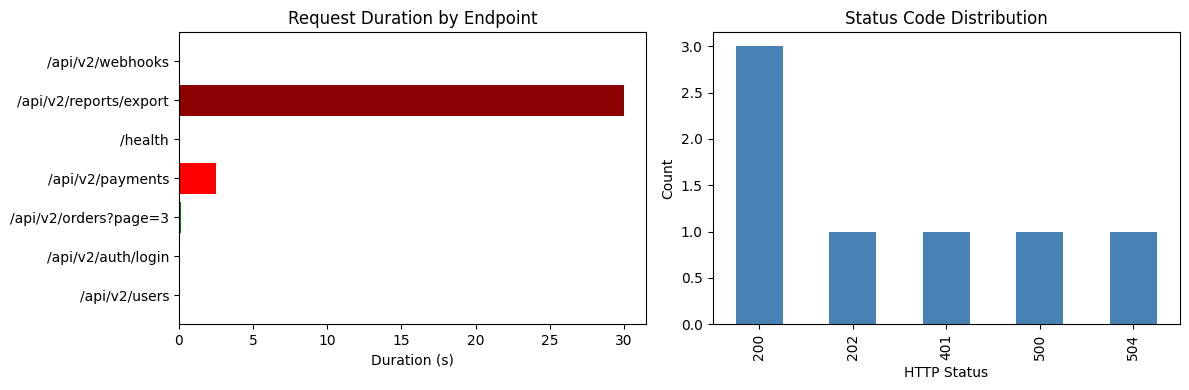

In [14]:
# Visualize response times by status
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = {200: 'green', 202: 'limegreen', 401: 'orange', 500: 'red', 504: 'darkred'}
c = [colors.get(s, 'gray') for s in syslog_df['status']]
ax1.barh(syslog_df['path'], syslog_df['duration'], color=c)
ax1.set_xlabel('Duration (s)')
ax1.set_title('Request Duration by Endpoint')

syslog_df['status'].value_counts().sort_index().plot.bar(ax=ax2, color='steelblue')
ax2.set_xlabel('HTTP Status')
ax2.set_ylabel('Count')
ax2.set_title('Status Code Distribution')

plt.tight_layout()
plt.show()

### How the regex works

The `HEADER_RE` pattern captures 10 named groups from a single line:

```
<134>2025-01-15T08:00:01.001Z webserver-01 nginx[2041]: GET /api/v2/users HTTP/1.1 200 1523 0.042
 ^^^  ^^^^^^^^^^^^^^^^^^^^^^^^^^  ^^^^^^^^^^^^  ^^^^^  ^^^^  ^^^  ^^^^^^^^^^^^  ^^^^^  ^^^  ^^^^  ^^^^^
 pri  timestamp                   hostname      proc   pid   meth path          proto  stat bytes dur
```

The `KV_RE` pattern handles continuation lines with both quoted and unquoted values:
```
  client=192.168.1.100 user_agent="Mozilla/5.0" request_id=req-a1b2c3
```

In [15]:
# Cleanup temp files
os.unlink(was_tmp.name)
os.unlink(hsm_tmp.name)
os.unlink(syslog_tmp.name)
print("Temp files cleaned up.")

Temp files cleaned up.


---
## Summary

| Approach | When to use |
|----------|-------------|
| `LogIngestor.ingest(path, type)` | Quick dispatch for supported formats (WAS, HSM, HDC, IBM_MQ, ZTNA) |
| Direct parser (e.g. `WASParser`) | When you need parser-specific configuration |
| Custom `BaseLogParser` subclass | For any log format — use regex for complex patterns |

All parsers return a `pd.DataFrame`, making them composable with the rest of the Sentinel pipeline.